# Downstream Classification from BYOL Embeddings

Evaluates how well the learned 256-dim projection embeddings support supervised classification.
Three classifiers are compared: **KNN**, **Random Forest**, and a **PyTorch MLP**.
No images are needed — classifiers train directly on the pre-extracted `.npy` feature files.

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay, f1_score, make_scorer,
)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

### 1.1 Configuration

Edit the three variables below before running the notebook.

| `LABEL_SET` | Columns | Classes |
|---|---|---|
| `"classical"` | 0–1 | FRI, FRII |
| `"classical_pure"` | 0–1 | FRI, FRII — sources with exactly one initial label (may have morphological labels) |
| `"initial"` | 0–4 | FRI, FRII, Hybrids, Spirals, Relaxed doubles |
| `"initial_pure"` | 0–4 | FRI, FRII, Hybrids, Spirals, Relaxed doubles — sources with exactly one initial label |
| `"environment"` | 16–19 | Cluster, Merger, Diffuse, Unknown |
| `"derived"` | computed | Pure hybrid, FR hybrid, Curved FRI, Curved FRII, Straight+multi-HS |
| `"morphology"` | 5–14 | C-curv … Restarted |
| `"all"` | 0–19 | All 20 classes |
| `"pure"` | 0–19 | All 20 classes, filtered to sources with exactly one label across all 20 |
| `"full"` | 0–19 | All 20 classes; when `EVAL_FRI_FRII_PURE=True`, evaluation is filtered to FRI/FRII-pure sources |

**Derived label definitions** (computed from label combinations, not raw columns):
1. **Pure hybrid**: Hybrid (col 2), *not* FRI and *not* FRII
2. **FR hybrid**: Hybrid (col 2) + FRI and/or FRII (col 0 or 1)
3. **Curved FRI**: FRI (col 0) + C- or S-curved (col 5 or 6)
4. **Curved FRII**: FRII (col 1) + C- or S-curved (col 5 or 6)
5. **Straight+multi-HS**: Straight jets (col 10) *and* Multi hotspots (col 11)

In [ ]:
# ── CONFIG ───────────────────────────────────────────────────────────────────
run_directory = "/users/mbredber/p3_SUPLAT/outputs/run_enb0_pca_pond_step_wd_20260424_0019"
LABEL_SET          = "classical_pure"    # "classical" | "classical_pure" | "initial" | "initial_pure" | "environment" | "derived" | "morphology" | "all" | "pure" | "full"
EVAL_FRI_FRII_PURE = False  # only used when LABEL_SET=="full": evaluate on FRI/FRII-pure sources only
SEED      = 42
N_FOLDS   = 1              # set to 5 (or more) to enable cross-validation
# ─────────────────────────────────────────────────────────────────────────────

run_name = Path(run_directory).name
project_location = Path(run_directory).parent
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

print(f"Run name         : {run_name}")
print(f"Project location : {project_location}")

## 2. Load Data

Reads the pre-extracted train and test projections saved by `create_embeddings.py`.
The splits are identical to those used during BYOL training (same seed).

In [19]:
emb_dir = project_location /  run_name / "embeddings"

X_train = np.load(emb_dir / "train_projections.npy").astype(np.float32)
y_train = np.load(emb_dir / "train_labels.npy").astype(np.int64)
X_test  = np.load(emb_dir / "test_projections.npy").astype(np.float32)
y_test  = np.load(emb_dir / "test_labels.npy").astype(np.int64)

print(f"Train embeddings : {X_train.shape}")
print(f"Train labels     : {y_train.shape}")
print(f"Test  embeddings : {X_test.shape}")
print(f"Test  labels     : {y_test.shape}")

Train embeddings : (5317, 256)
Train labels     : (5317, 20)
Test  embeddings : (1140, 256)
Test  labels     : (1140, 20)


### 2.1 Feature normalisation

`StandardScaler` is fit on the training embeddings only and applied to both splits. Essential for KNN (distance-based) and Logistic Regression. RF is scale-invariant; the MLP uses BatchNorm internally.

In [20]:
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print(f'Train mean (first 3 dims): {X_train_s.mean(axis=0)[:3].round(4)}')
print(f'Train std  (first 3 dims): {X_train_s.std(axis=0)[:3].round(4)}')

Train mean (first 3 dims): [ 0. -0. -0.]
Train std  (first 3 dims): [1. 1. 1.]


### 2.2 Label subset selection

In [ ]:
ALL_CLASS_NAMES = [
    'FRI', 'FRII', 'Hybrids', 'Spirals', 'Relaxed doubles',
    'C-curv', 'S-curv', 'Misalign', 'Wings', 'X-shaped',
    'Straight jets', 'Multi hotspots', 'Cont. jets', 'Banding',
    'One-sided', 'Restarted', 'Cluster', 'Merger', 'Diffuse', 'Unknown',
]

DERIVED_CLASS_NAMES = [
    'Pure hybrid',       # col2 & ~col0 & ~col1
    'FR hybrid',         # col2 & (col0 | col1)
    'Curved FRI',        # col0 & (col5 | col6)
    'Curved FRII',       # col1 & (col5 | col6)
    'Straight+multi-HS', # col10 & col11
]

LABEL_SETS = {
    "classical":      [0, 1],
    "classical_pure": [0, 1],
    "initial":        list(range(0, 5)),
    "initial_pure":   list(range(0, 5)),
    "environment":    list(range(16, 20)),
    "derived":        None,  # computed from label combinations
    "morphology":     list(range(5, 15)),
    "all":            list(range(0, 20)),
    "pure":           list(range(0, 20)),
    "full":           list(range(0, 20)),
}

label_cols = LABEL_SETS[LABEL_SET]

# For "derived": compute 5 boolean combination columns
if LABEL_SET == "derived":
    def _make_derived(y):
        c = lambda i: y[:, i].astype(bool)
        return np.stack([
            ( c(2) & ~c(0) & ~c(1)).astype(np.int64),   # Pure hybrid
            ( c(2) &  (c(0) | c(1))).astype(np.int64),  # FR hybrid
            ( c(0) &  (c(5) | c(6))).astype(np.int64),  # Curved FRI
            ( c(1) &  (c(5) | c(6))).astype(np.int64),  # Curved FRII
            (c(10) &   c(11)).astype(np.int64),          # Straight + multi-HS
        ], axis=1)
    y_train_sub = _make_derived(y_train)
    y_test_sub  = _make_derived(y_test)
    class_names = DERIVED_CLASS_NAMES
else:
    y_train_sub = y_train[:, label_cols]
    y_test_sub  = y_test[:, label_cols]
    class_names = [ALL_CLASS_NAMES[i] for i in label_cols]

n_classes = len(class_names)

# Pure filtering
if LABEL_SET == "pure":
    train_pure  = y_train.sum(axis=1) == 1
    test_pure   = y_test.sum(axis=1)  == 1
    X_train_s   = X_train_s[train_pure]
    X_test_s    = X_test_s[test_pure]
    y_train_sub = y_train_sub[train_pure]
    y_test_sub  = y_test_sub[test_pure]
    print(f"Pure filter (all 20)   : {train_pure.sum()} train / {test_pure.sum()} test retained")
elif LABEL_SET in ("classical_pure", "initial_pure"):
    # Keep sources with exactly one initial label (cols 0-4); morphological labels allowed
    train_pure  = y_train[:, 0:5].sum(axis=1) == 1
    test_pure   = y_test[:, 0:5].sum(axis=1)  == 1
    X_train_s   = X_train_s[train_pure]
    X_test_s    = X_test_s[test_pure]
    y_train_sub = y_train_sub[train_pure]
    y_test_sub  = y_test_sub[test_pure]
    print(f"Initial-pure filter    : {train_pure.sum()} train / {test_pure.sum()} test retained")

if LABEL_SET == "full" and EVAL_FRI_FRII_PURE:
    # Training data is NOT filtered — model trains on all 20 classes / all samples.
    # Only the test set is restricted to FRI/FRII-pure sources for evaluation.
    fri_frii_pure_te = (y_test[:, 0:5].sum(axis=1) == 1) & (y_test[:, 0] | y_test[:, 1]).astype(bool)
    X_test_s    = X_test_s[fri_frii_pure_te]
    y_test_sub  = y_test_sub[fri_frii_pure_te]
    print(f"FRI/FRII-pure eval filter : {fri_frii_pure_te.sum()} test samples retained")

print(f"Label set  : {LABEL_SET}")
print(f"n_classes  : {n_classes}")
print(f"Classes    : {class_names}")

### 2.3 Class distribution

Positive sample count per class in train and test.

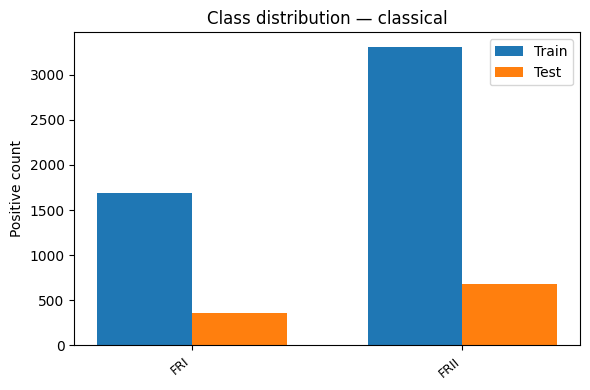

Class distribution:
  FRI             :  1688 train /   355 test
  FRII            :  3304 train /   680 test


In [44]:
train_counts = y_train_sub.sum(axis=0)
test_counts  = y_test_sub.sum(axis=0)

x = np.arange(n_classes)
width = 0.35
fig, ax = plt.subplots(figsize=(max(6, n_classes * 0.9), 4))
ax.bar(x - width/2, train_counts, width, label='Train')
ax.bar(x + width/2, test_counts,  width, label='Test')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Positive count')
ax.set_title(f'Class distribution — {LABEL_SET}')
ax.legend()
plt.tight_layout()
plt.show()

# Print out the actual numbers for reference
print("Class distribution:")
for i, cls in enumerate(class_names):
    print(f"  {cls:15s} : {train_counts[i]:5d} train / {test_counts[i]:5d} test")

### 2.4 Evaluation helpers

Shared functions used by all classifiers.

In [23]:
def evaluate(y_true, y_pred, y_prob, name, class_names):
    """Print classification report, plot confusion matrices, compute ROC-AUC."""
    n = len(class_names)
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(classification_report(y_true, y_pred, target_names=class_names,
                                zero_division=0))

    # ── Accuracy and AUC summary ──────────────────────────────────────────
    from sklearn.metrics import accuracy_score
    accuracy = accuracy_score(y_true.reshape(-1), y_pred.reshape(-1))
    per_class_acc = [(y_true[:, i] == y_pred[:, i]).mean() for i in range(n)]
    aucs = []
    for i in range(n):
        if len(np.unique(y_true[:, i])) < 2:
            aucs.append(float('nan'))
        else:
            aucs.append(roc_auc_score(y_true[:, i], y_prob[:, i]))
    macro_auc = np.nanmean(aucs)

    print(f"{'Accuracy (all labels):':<30} {accuracy:.4f}")
    print(f"{'Macro ROC-AUC:':<30} {macro_auc:.4f}")
    print()
    print(f"  {'Class':<22} {'Accuracy':>10} {'ROC-AUC':>10}")
    print(f"  {'-'*44}")
    for cname, acc, auc in zip(class_names, per_class_acc, aucs):
        auc_str = f"{auc:.4f}" if not np.isnan(auc) else "   n/a"
        print(f"  {cname:<22} {acc:>10.4f} {auc_str:>10}")

    # ── Confusion matrices ────────────────────────────────────────────────
    cols = min(n, 5)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.2, rows * 3.2))
    axes = np.array(axes).reshape(-1)
    for i, (cname, acc) in enumerate(zip(class_names, per_class_acc)):
        cm = confusion_matrix(y_true[:, i], y_pred[:, i])
        disp = ConfusionMatrixDisplay(cm, display_labels=['Neg', 'Pos'])
        disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
        axes[i].set_title(f"{cname}  (acc={acc:.3f})", fontsize=9)
    for j in range(n, len(axes)):
        axes[j].axis('off')
    fig.suptitle(f'{name} — Confusion matrices', fontsize=11)
    plt.tight_layout()
    plt.show()

    # ── ROC-AUC bar chart ─────────────────────────────────────────────────
    fig_w = max(8, n * 0.9)
    fig_h = 3.5 + max(0, (n - 10) * 0.1)   # extra height for rotated labels
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    colors = ['steelblue' if not np.isnan(a) else 'lightgrey' for a in aucs]
    ax.bar(range(n), aucs, color=colors)
    ax.set_xticks(range(n))
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
    ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='random')
    ax.axhline(macro_auc, color='green', linestyle='--', linewidth=1,
               label=f'macro avg = {macro_auc:.3f}')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('ROC-AUC')
    ax.set_title(f'{name} — ROC-AUC per class')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    return {
        'f1_per_class':  f1_score(y_true, y_pred, average=None, zero_division=0),
        'f1_macro':      f1_score(y_true, y_pred, average='macro', zero_division=0),
        'auc_per_class': np.array(aucs),
        'auc_macro':     macro_auc,
        'accuracy':      accuracy,
    }


## 3. Dummy Baseline

Predicts each label by sampling from the training label distribution independently. Sets the performance floor — every real classifier should beat this.

In [24]:
dummy_base = DummyClassifier(strategy='stratified', random_state=SEED)
dummy      = MultiOutputClassifier(dummy_base)
dummy.fit(X_train_s, y_train_sub)
print('Dummy classifier fitted.')

Dummy classifier fitted.



  Dummy (stratified)
              precision    recall  f1-score   support

         FRI       0.30      0.30      0.30       355
        FRII       0.59      0.62      0.60       680

   micro avg       0.49      0.51      0.50      1035
   macro avg       0.44      0.46      0.45      1035
weighted avg       0.49      0.51      0.50      1035
 samples avg       0.46      0.44      0.45      1035

Accuracy (all labels):         0.5377
Macro ROC-AUC:                 0.4895

  Class                    Accuracy    ROC-AUC
  --------------------------------------------
  FRI                        0.5623     0.4908
  FRII                       0.5132     0.4882


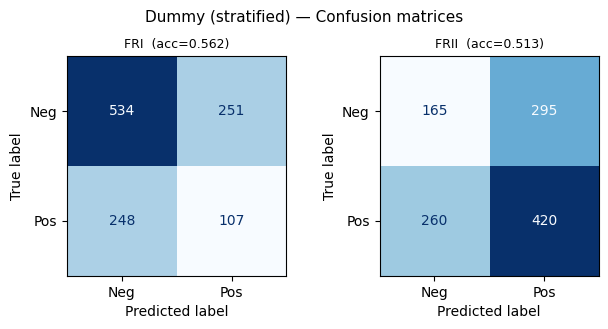

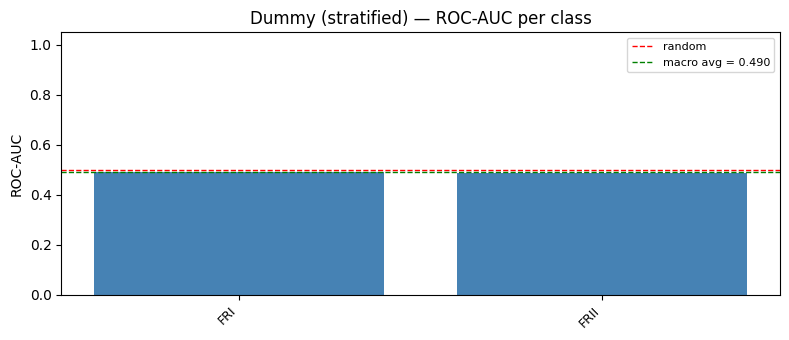

In [25]:
y_pred_dummy = dummy.predict(X_test_s)
y_prob_dummy = y_pred_dummy.astype(float)  # 0/1 as probability proxy
results_dummy = evaluate(y_test_sub, y_pred_dummy, y_prob_dummy,
                         'Dummy (stratified)', class_names)

## 4. KNN Classifier

k-Nearest Neighbours in the 256-dim scaled embedding space. Each label is treated as an independent binary classification problem via `MultiOutputClassifier`.

In [28]:
knn_base = KNeighborsClassifier(n_neighbors=15, metric='euclidean', n_jobs=-1)
knn      = MultiOutputClassifier(knn_base)
knn.fit(X_train_s, y_train_sub)
print('KNN fitted.')

KNN fitted.



  KNN
              precision    recall  f1-score   support

         FRI       0.73      0.68      0.70       355
        FRII       0.84      0.86      0.85       680

   micro avg       0.81      0.80      0.80      1035
   macro avg       0.79      0.77      0.78      1035
weighted avg       0.80      0.80      0.80      1035
 samples avg       0.71      0.70      0.70      1035

Accuracy (all labels):         0.8215
Macro ROC-AUC:                 0.8793

  Class                    Accuracy    ROC-AUC
  --------------------------------------------
  FRI                        0.8202     0.8736
  FRII                       0.8228     0.8850


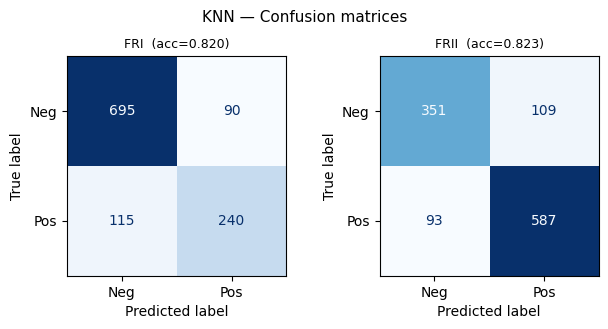

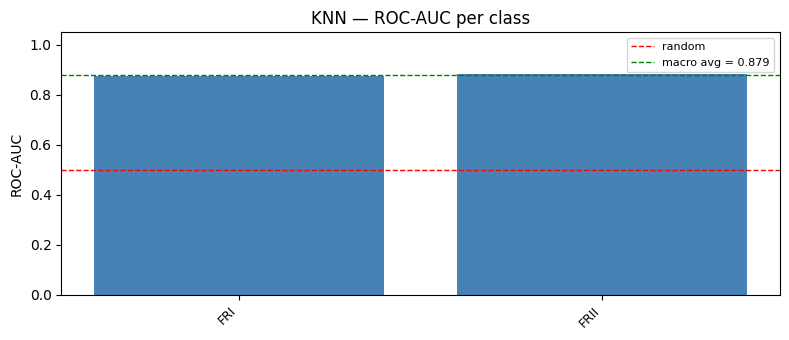

In [29]:
y_pred_knn = knn.predict(X_test_s)
y_prob_knn = np.stack(
    [est.predict_proba(X_test_s)[:, 1] for est in knn.estimators_], axis=1
)
results_knn = evaluate(y_test_sub, y_pred_knn, y_prob_knn, 'KNN', class_names)

In [ ]:
scorer = make_scorer(f1_score, average='macro', zero_division=0)
if N_FOLDS > 1:
    cv_scores_knn = cross_val_score(
        MultiOutputClassifier(KNeighborsClassifier(n_neighbors=15,
                                                   metric='euclidean', n_jobs=-1)),
        X_train_s, y_train_sub, cv=N_FOLDS, scoring=scorer, n_jobs=-1
    )
    print(f'KNN  {N_FOLDS}-fold CV macro-F1: {cv_scores_knn.mean():.4f} ± {cv_scores_knn.std():.4f}')
else:
    print("CV skipped (N_FOLDS=1). Set N_FOLDS > 1 to enable.")


## 5. Random Forest Classifier

200-tree Random Forest. `MultiOutputClassifier` wraps it for multi-label output.

In [33]:
rf_base = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
rf      = MultiOutputClassifier(rf_base)
rf.fit(X_train_s, y_train_sub)
print('Random Forest fitted.')

Random Forest fitted.



  Random Forest
              precision    recall  f1-score   support

         FRI       0.75      0.66      0.71       355
        FRII       0.84      0.88      0.86       680

   micro avg       0.81      0.81      0.81      1035
   macro avg       0.79      0.77      0.78      1035
weighted avg       0.81      0.81      0.81      1035
 samples avg       0.72      0.71      0.71      1035

Accuracy (all labels):         0.8263
Macro ROC-AUC:                 0.8828

  Class                    Accuracy    ROC-AUC
  --------------------------------------------
  FRI                        0.8272     0.8755
  FRII                       0.8254     0.8901


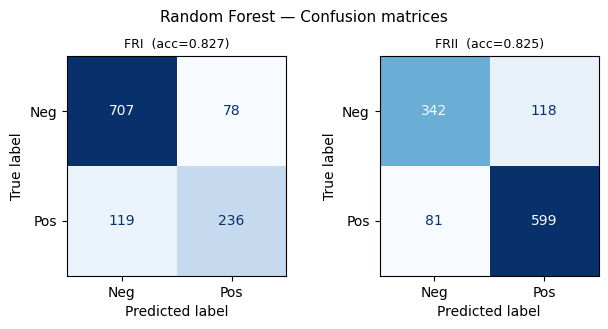

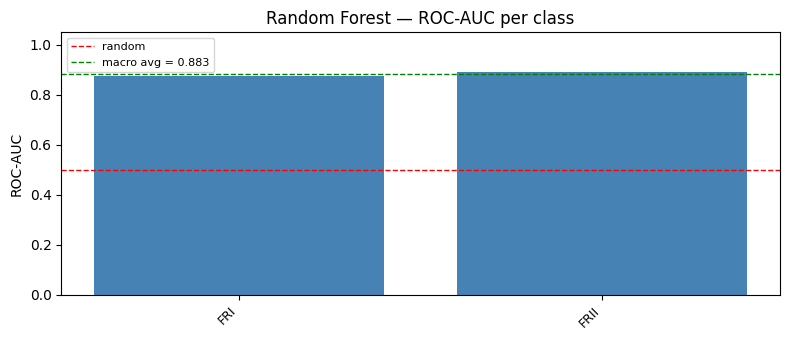

In [34]:
y_pred_rf = rf.predict(X_test_s)
y_prob_rf = np.stack(
    [est.predict_proba(X_test_s)[:, 1] for est in rf.estimators_], axis=1
)
results_rf = evaluate(y_test_sub, y_pred_rf, y_prob_rf, 'Random Forest', class_names)

In [ ]:
if N_FOLDS > 1:
    cv_scores_rf = cross_val_score(
        MultiOutputClassifier(RandomForestClassifier(n_estimators=200,
                                                     random_state=SEED, n_jobs=-1)),
        X_train_s, y_train_sub, cv=N_FOLDS, scoring=scorer, n_jobs=-1
    )
    print(f'RF   {N_FOLDS}-fold CV macro-F1: {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}')
else:
    print("CV skipped (N_FOLDS=1). Set N_FOLDS > 1 to enable.")


## 6. Logistic Regression

A linear probe on the scaled embeddings — the standard way to test whether the BYOL embedding space is already linearly separable. If LR performance is close to RF/MLP, the nonlinear classifiers add little beyond what the encoder already provides.

In [36]:
lr_base = LogisticRegression(max_iter=1000, random_state=SEED, n_jobs=-1)
lr      = MultiOutputClassifier(lr_base)
lr.fit(X_train_s, y_train_sub)
print('Logistic Regression fitted.')

Logistic Regression fitted.



  Logistic Regression
              precision    recall  f1-score   support

         FRI       0.75      0.66      0.70       355
        FRII       0.84      0.89      0.86       680

   micro avg       0.81      0.81      0.81      1035
   macro avg       0.79      0.78      0.78      1035
weighted avg       0.81      0.81      0.81      1035
 samples avg       0.71      0.71      0.71      1035

Accuracy (all labels):         0.8289
Macro ROC-AUC:                 0.8932

  Class                    Accuracy    ROC-AUC
  --------------------------------------------
  FRI                        0.8246     0.8812
  FRII                       0.8333     0.9051


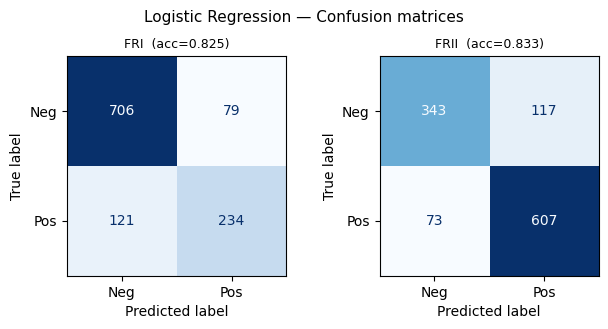

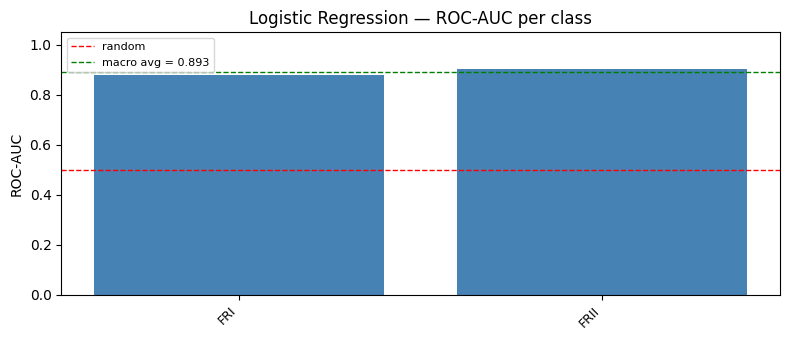

In [37]:
y_pred_lr = lr.predict(X_test_s)
y_prob_lr = np.stack(
    [est.predict_proba(X_test_s)[:, 1] for est in lr.estimators_], axis=1
)
results_lr = evaluate(y_test_sub, y_pred_lr, y_prob_lr,
                      'Logistic Regression', class_names)

In [ ]:
if N_FOLDS > 1:
    cv_scores_lr = cross_val_score(
        MultiOutputClassifier(LogisticRegression(max_iter=1000,
                                                 random_state=SEED, n_jobs=-1)),
        X_train_s, y_train_sub, cv=N_FOLDS, scoring=scorer, n_jobs=-1
    )
    print(f'LR   {N_FOLDS}-fold CV macro-F1: {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}')
else:
    print("CV skipped (N_FOLDS=1). Set N_FOLDS > 1 to enable.")


## 7. MLP Classifier (PyTorch)

Two-hidden-layer MLP. For each source the head outputs `(n_classes, 2)` logits — one logit pair per class. Row-wise softmax gives the probability of belonging to that class. Loss is cross-entropy summed over all `N × n_classes` binary decisions.

In [39]:
class MultiLabelMLP(nn.Module):
    def __init__(self, in_dim: int, n_classes: int,
                 hidden=(512, 256), dropout=0.3):
        super().__init__()
        layers, prev = [], in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h),
                       nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        self.encoder   = nn.Sequential(*layers)
        self.head      = nn.Linear(prev, n_classes * 2)
        self.n_classes = n_classes

    def forward(self, x):
        return self.head(self.encoder(x)).view(-1, self.n_classes, 2)

mlp = MultiLabelMLP(in_dim=X_train_s.shape[1], n_classes=n_classes).to(device)

# ── Parameter summary ────────────────────────────────────────────────────────
print(f"{'Layer':<35} {'Shape':>20} {'Params':>10}")
print('-' * 67)
total = 0
for name, param in mlp.named_parameters():
    n = param.numel()
    total += n
    print(f"{name:<35} {str(tuple(param.shape)):>20} {n:>10,}")
print('-' * 67)
print(f"{'Total':<35} {'':>20} {total:>10,}")


Layer                                              Shape     Params
-------------------------------------------------------------------
encoder.0.weight                              (512, 256)    131,072
encoder.0.bias                                    (512,)        512
encoder.1.weight                                  (512,)        512
encoder.1.bias                                    (512,)        512
encoder.4.weight                              (256, 512)    131,072
encoder.4.bias                                    (256,)        256
encoder.5.weight                                  (256,)        256
encoder.5.bias                                    (256,)        256
head.weight                                     (4, 256)      1,024
head.bias                                           (4,)          4
-------------------------------------------------------------------
Total                                                       265,476


/users/mbredber/.venv/lib64/python3.11/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch  10  train=0.3243  val=0.3181  lr=5.00e-04
Epoch  20  train=0.3108  val=0.3108  lr=5.00e-04
Epoch  30  train=0.2975  val=0.3110  lr=2.50e-04
Early stopping at epoch 37 (no improvement for 15 epochs)

Restored best model (val loss = 0.3058)


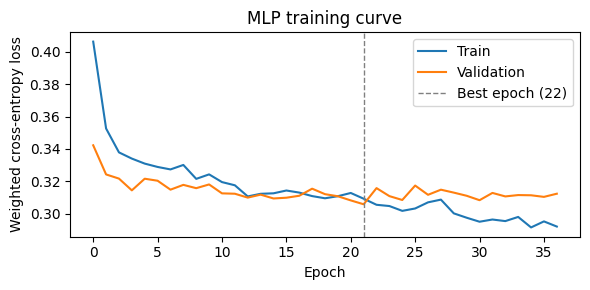

In [40]:
# ── Hyper-parameters ─────────────────────────────────────────────────────────
N_EPOCHS          = 100
BATCH_SIZE        = 256
LR                = 1e-3
WEIGHT_DECAY      = 1e-4   # L2 regularisation
VAL_FRAC          = 0.15
PATIENCE          = 15     # early stopping: stop if val loss doesn't improve
# ─────────────────────────────────────────────────────────────────────────────

torch.manual_seed(SEED)
rng = np.random.default_rng(SEED)

# ── Train / val split ────────────────────────────────────────────────────────
n_val         = int(len(X_train_s) * VAL_FRAC)
val_idx_mlp   = rng.choice(len(X_train_s), size=n_val, replace=False)
train_idx_mlp = np.setdiff1d(np.arange(len(X_train_s)), val_idx_mlp)

X_tr_t  = torch.from_numpy(X_train_s[train_idx_mlp])
y_tr_t  = torch.from_numpy(y_train_sub[train_idx_mlp].astype(np.int64))
X_val_t = torch.from_numpy(X_train_s[val_idx_mlp])
y_val_t = torch.from_numpy(y_train_sub[val_idx_mlp].astype(np.int64))

train_dl = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                      batch_size=BATCH_SIZE, shuffle=True)

# ── Class weights: upweight rare positive classes ────────────────────────────
# For each class: weight_pos = n_neg / n_pos  (clipped to avoid explosion)
pos_counts  = y_tr_t.float().sum(dim=0).clamp(min=1)
neg_counts  = len(y_tr_t) - pos_counts
pos_weights = (neg_counts / pos_counts).clamp(max=20).to(device)  # (n_classes,)

# ── Optimiser + LR scheduler ─────────────────────────────────────────────────
optimiser = torch.optim.Adam(mlp.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiser, mode='min', factor=0.5, patience=5, verbose=True
)

# ── Training loop ─────────────────────────────────────────────────────────────
train_losses, val_losses = [], []
best_val_loss  = float('inf')
best_state     = None
epochs_no_impr = 0

for epoch in range(1, N_EPOCHS + 1):
    # Train
    mlp.train()
    epoch_loss = 0.0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        logits = mlp(xb)                              # (B, n_classes, 2)
        # Weighted cross-entropy: repeat pos_weights for each sample
        loss = sum(
            F.cross_entropy(logits[:, c, :], yb[:, c],
                            weight=torch.tensor([1.0, pos_weights[c].item()],
                                                device=device))
            for c in range(n_classes)
        ) / n_classes
        optimiser.zero_grad()
        loss.backward()
        optimiser.step()
        epoch_loss += loss.item() * len(xb)
    train_losses.append(epoch_loss / len(X_tr_t))

    # Validate
    mlp.eval()
    with torch.no_grad():
        val_logits = mlp(X_val_t.to(device))
        val_loss = sum(
            F.cross_entropy(val_logits[:, c, :], y_val_t[:, c].to(device),
                            weight=torch.tensor([1.0, pos_weights[c].item()],
                                                device=device))
            for c in range(n_classes)
        ).item() / n_classes
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss  = val_loss
        best_state     = {k: v.cpu().clone() for k, v in mlp.state_dict().items()}
        epochs_no_impr = 0
    else:
        epochs_no_impr += 1
        if epochs_no_impr >= PATIENCE:
            print(f"Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)")
            break

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}  train={train_losses[-1]:.4f}  "
              f"val={val_losses[-1]:.4f}  lr={optimiser.param_groups[0]['lr']:.2e}")

# Restore best weights
mlp.load_state_dict(best_state)
print(f"\nRestored best model (val loss = {best_val_loss:.4f})")

# Plot
plt.figure(figsize=(6, 3))
plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Validation')
best_ep = int(np.argmin(val_losses))
plt.axvline(best_ep, color='grey', linestyle='--', linewidth=1,
            label=f'Best epoch ({best_ep + 1})')
plt.xlabel('Epoch')
plt.ylabel('Weighted cross-entropy loss')
plt.title('MLP training curve')
plt.legend()
plt.tight_layout()
plt.show()



  MLP (PyTorch)
              precision    recall  f1-score   support

         FRI       0.66      0.81      0.73       355
        FRII       0.87      0.84      0.85       680

   micro avg       0.78      0.83      0.81      1035
   macro avg       0.76      0.82      0.79      1035
weighted avg       0.80      0.83      0.81      1035
 samples avg       0.72      0.73      0.72      1035

Accuracy (all labels):         0.8184
Macro ROC-AUC:                 0.8919

  Class                    Accuracy    ROC-AUC
  --------------------------------------------
  FRI                        0.8096     0.8821
  FRII                       0.8272     0.9017


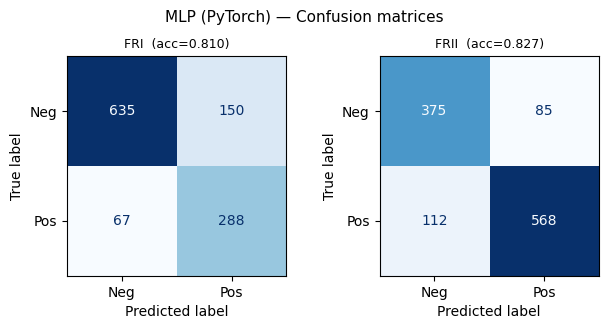

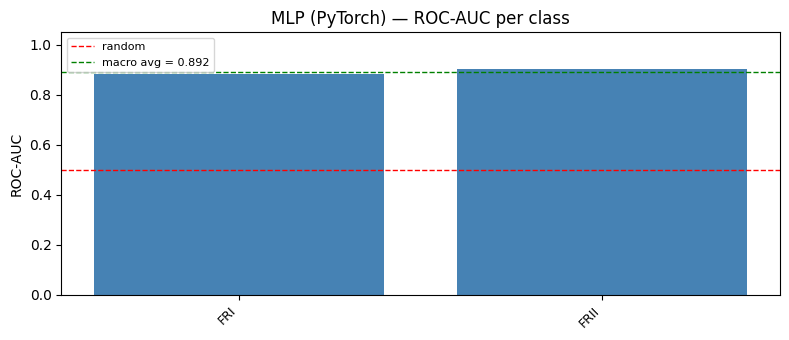

In [41]:
mlp.eval()
with torch.no_grad():
    logits_test = mlp(torch.from_numpy(X_test_s).to(device))  # (N, n_classes, 2)
    probs_test  = F.softmax(logits_test, dim=-1)             # (N, n_classes, 2)

y_prob_mlp = probs_test[:, :, 1].cpu().numpy()              # P(positive) per class
y_pred_mlp = (y_prob_mlp >= 0.5).astype(int)

results_mlp = evaluate(y_test_sub, y_pred_mlp, y_prob_mlp,
                       "MLP (PyTorch)", class_names)

## 7.5  Fine-tuned EfficientNet-B0 (ENB0)

Results loaded from `{run_directory}/baselines/enb0/`, produced by:

```bash
python scripts/train_baseline_classifiers.py --model enb0 --run_dir <run> --data_dir <data>
```

ENB0 is trained end-to-end on the same train/test split with identical weighted cross-entropy
loss, `ReduceLROnPlateau` scheduler, and early stopping as the MLP above.


In [ ]:
import json as _json

_enb0_base = project_location / run_name / 'baselines'
_enb0_candidates = sorted(_enb0_base.glob(f'{run_name}_enb0_*')) if _enb0_base.exists() else []
_enb0_dir = _enb0_candidates[-1] if _enb0_candidates else None  # most recent by name

results_enb0 = None
if _enb0_dir is not None and (_enb0_dir / 'results.json').exists():
    with open(_enb0_dir / 'results.json') as _f:
        _r = _json.load(_f)
    results_enb0 = {
        'f1_macro':      _r['f1_macro'],
        'auc_macro':     _r['auc_macro'],
        'accuracy':      _r['accuracy'],
        'f1_per_class':  np.array(_r['f1_per_class']),
        'auc_per_class': np.array([a if a is not None else np.nan
                                   for a in _r['auc_per_class']]),
    }
    _probs_path = _enb0_dir / 'test_probs.npy'
    if _probs_path.exists():
        results_enb0['y_prob'] = np.load(_probs_path)
    print(f"ENB0  — Macro F1: {results_enb0['f1_macro']:.4f}  "
          f"Macro AUC: {results_enb0['auc_macro']:.4f}  "
          f"Accuracy: {results_enb0['accuracy']:.4f}")
    print(f"  (loaded from {_enb0_dir.name})")
else:
    print(f"WARNING: No ENB0 results found under {_enb0_base}")
    print("Run:  python scripts/train_baseline_classifiers.py --model enb0 "
          "--run_dir <run> --data_dir <data>")

## 7.6  End-to-end Baseline Results

Loads results for CNN, ViT-B/16, DualSSN, ScatterNet, SimpleScatterNet from
`{run_directory}/baselines/{model}/results.json` — produced by `train_baseline_classifiers.py`.
Missing models are skipped with a warning.


In [ ]:
import json as _json

_BASELINE_MODELS = ['cnn', 'vit', 'dualssn', 'scatternet', 'simplescatternet']
_baseline_display = {
    'cnn':              'CNN',
    'vit':              'ViT-B/16',
    'dualssn':          'DualSSN',
    'scatternet':       'ScatterNet',
    'simplescatternet': 'SimpleScatterNet',
}

_baselines_base = project_location / run_name / 'baselines'

baseline_results = {}
for _m in _BASELINE_MODELS:
    _candidates = sorted(_baselines_base.glob(f'{run_name}_{_m}_*')) if _baselines_base.exists() else []
    _mdir = _candidates[-1] if _candidates else None
    if _mdir is not None and (_mdir / 'results.json').exists():
        with open(_mdir / 'results.json') as _f:
            _r = _json.load(_f)
        baseline_results[_baseline_display[_m]] = {
            'f1_macro':      _r['f1_macro'],
            'auc_macro':     _r['auc_macro'],
            'accuracy':      _r['accuracy'],
            'f1_per_class':  np.array(_r['f1_per_class']),
            'auc_per_class': np.array([a if a is not None else np.nan
                                       for a in _r['auc_per_class']]),
        }
        _probs_path = _mdir / 'test_probs.npy'
        if _probs_path.exists():
            baseline_results[_baseline_display[_m]]['y_prob'] = np.load(_probs_path)
        print(f"{_baseline_display[_m]:<18} — Macro F1: {_r['f1_macro']:.4f}  "
              f"Macro AUC: {_r['auc_macro']:.4f}  Accuracy: {_r['accuracy']:.4f}")
        print(f"  (loaded from {_mdir.name})")
    else:
        print(f"WARNING: {_baseline_display[_m]} results not found under {_baselines_base}")

print(f"\nLoaded {len(baseline_results)} / {len(_BASELINE_MODELS)} end-to-end baselines.")

## 8. Classifier Comparison

Side-by-side bar charts of per-class F1 and a summary table of macro-averaged scores.

In [ ]:
# ── Build combined classifier dict ───────────────────────────────────────────
all_classifiers = {
    'Dummy': results_dummy,
    'LR':    results_lr,
    'KNN':   results_knn,
    'RF':    results_rf,
    'MLP':   results_mlp,
}

if results_enb0 is not None:
    all_classifiers['ENB0'] = results_enb0

all_classifiers.update(baseline_results)

if not all_classifiers:
    print("No classifier results available.")
else:
    names  = list(all_classifiers.keys())
    f1s    = [all_classifiers[n]['f1_macro']  for n in names]
    aucs   = [all_classifiers[n]['auc_macro'] for n in names]
    accs   = [all_classifiers[n]['accuracy']  for n in names]

    x     = np.arange(len(names))
    w     = 0.35
    fig, ax = plt.subplots(figsize=(max(8, len(names) * 1.1), 4))
    bars_f1  = ax.bar(x - w / 2, f1s,  w, label='Macro F1',  color='steelblue',  alpha=0.85)
    bars_auc = ax.bar(x + w / 2, aucs, w, label='Macro AUC', color='darkorange', alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.set_title(f'Global metrics — {LABEL_SET} labels  |  {run_name}')
    ax.legend()
    ax.axhline(0.5, color='grey', linestyle=':', linewidth=0.8)
    plt.tight_layout()
    plt.show()


In [ ]:
print(f"\n{'Classifier':<22} {'Macro F1':>10} {'Macro AUC':>10} {'Accuracy':>10}")
print('-' * 56)
for name, res in all_classifiers.items():
    print(f"{name:<22} {res['f1_macro']:>10.4f} "
          f"{res['auc_macro']:>10.4f} {res['accuracy']:>10.4f}")


## 9. Ensemble Classification

Averages predicted probabilities from the top-N classifiers (ranked by macro F1) and evaluates the ensemble using the same `evaluate()` function.

In [ ]:
# ── Collect y_prob arrays from all available classifiers ─────────────────────
all_y_probs = {
    'KNN': y_prob_knn,
    'RF':  y_prob_rf,
    'LR':  y_prob_lr,
    'MLP': y_prob_mlp,
}
if results_enb0 is not None and 'y_prob' in results_enb0:
    all_y_probs['ENB0'] = results_enb0['y_prob']
for _name, _res in baseline_results.items():
    if 'y_prob' in _res:
        all_y_probs[_name] = _res['y_prob']

# ── Rank by macro F1 (descending) ────────────────────────────────────────────
ranked = sorted(
    [(n, all_classifiers[n]['f1_macro']) for n in all_y_probs if n in all_classifiers],
    key=lambda x: x[1], reverse=True
)
print("Classifiers available for ensemble (ranked by macro F1):")
for rank, (n, f1) in enumerate(ranked, 1):
    print(f"  {rank}. {n:<22} macro F1 = {f1:.4f}")

# ── Build ensembles ───────────────────────────────────────────────────────────
def make_ensemble(names, all_y_probs):
    stack = np.stack([all_y_probs[n] for n in names], axis=0)  # (K, N, C)
    return stack.mean(axis=0)                                   # (N, C)

top1_names = [ranked[0][0]] if len(ranked) >= 1 else []
top5_names = [n for n, _ in ranked[:5]]

if top1_names:
    y_prob_ens1 = make_ensemble(top1_names, all_y_probs)
    y_pred_ens1 = (y_prob_ens1 >= 0.5).astype(int)
    print(f"\nTop-1 ensemble: {top1_names}")
    results_ens1 = evaluate(y_test_sub, y_pred_ens1, y_prob_ens1, 'Ensemble Top-1', class_names)
else:
    results_ens1 = None

if len(top5_names) > 1:
    y_prob_ens5 = make_ensemble(top5_names, all_y_probs)
    y_pred_ens5 = (y_prob_ens5 >= 0.5).astype(int)
    print(f"\nTop-5 ensemble: {top5_names}")
    results_ens5 = evaluate(y_test_sub, y_pred_ens5, y_prob_ens5, 'Ensemble Top-5', class_names)
else:
    results_ens5 = None

# ── Extended comparison table ─────────────────────────────────────────────────
ens_classifiers = dict(all_classifiers)
if results_ens1 is not None:
    ens_classifiers['Ensemble Top-1'] = results_ens1
if results_ens5 is not None:
    ens_classifiers['Ensemble Top-5'] = results_ens5

print(f"\n{'Classifier':<22} {'Macro F1':>10} {'Macro AUC':>10} {'Accuracy':>10}")
print('-' * 56)
for name, res in ens_classifiers.items():
    print(f"{name:<22} {res['f1_macro']:>10.4f} "
          f"{res['auc_macro']:>10.4f} {res['accuracy']:>10.4f}")
